In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch


First we split our dataset. We're loading the dataset using `datasets.MNIST`. This method automatically splits the dataset into train and "non-train" or test datasets. So we directly split into train and test data with this method and then we take 10,000 observations from the train dataset to create the validation dataset.

In [3]:

full_train = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

training_data, validation_data = random_split(
    full_train,
    [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

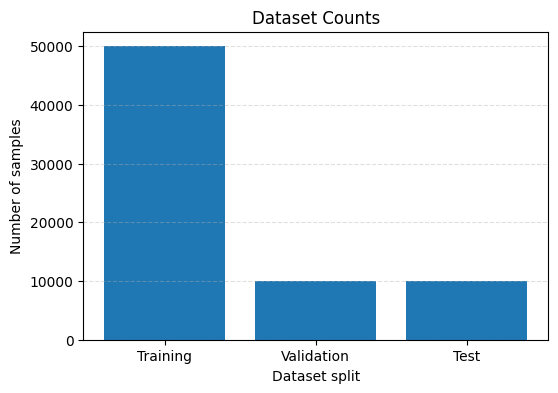

In [4]:
plt.figure(figsize=(6, 4))
dataset_counts = [len(training_data), len(validation_data), len(test_data)]
dataset_labels = ["Training", "Validation", "Test"]
plt.bar(dataset_labels, dataset_counts)
plt.title("Dataset Counts")
plt.ylabel("Number of samples")
plt.xlabel("Dataset split")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

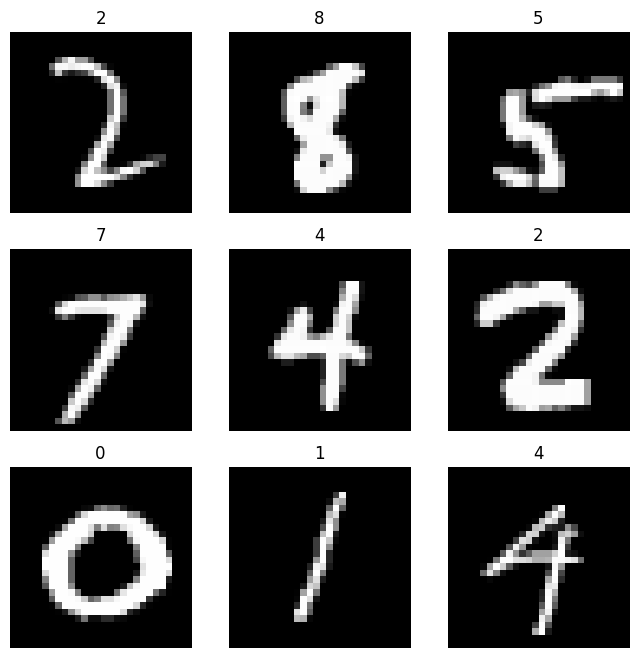

In [5]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

networks = [
    { "name": "Net1", "hidden": [128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 15 },
    { "name": "Net2", "hidden": [256, 128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 15 },
    { "name": "Net3", "hidden": [256, 128, 64], "optimizer":  "sgd", "lr": 0.01, "batch_size": 64, "epochs": 15 }
]

class FeedForwardNN(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        sizes = [784] + hidden_sizes + [10]
        self.layers = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)
        ])

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x

In [7]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    correct    = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output      = model(X_batch)
            total_loss += loss_fn(output, y_batch).item()
            correct    += (output.argmax(1) == y_batch).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


In [8]:
val_loader  = DataLoader(validation_data,  batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

results = []
for net in networks:
    print(f"\n- {net['name']}")

    model   = FeedForwardNN(hidden_sizes=net["hidden"])
    loss_fn = nn.CrossEntropyLoss()

    if net["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=net["lr"])
    elif net["optimizer"] == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=net["lr"])

    train_loader = DataLoader(training_data, batch_size=net["batch_size"], shuffle=True)

    prev_val_loss = None
    stopped_early = False

    # train per network
    for epoch in range(net["epochs"]):
        model.train()
        for X_batch, y_batch in train_loader:
            output = model(X_batch)
            loss = loss_fn(output, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        print(f"  Epoch {epoch + 1}/{net['epochs']}  val_loss={val_loss}  val_acc={val_acc}")

        # early stopping
        if prev_val_loss is not None and val_loss > prev_val_loss:
            print(f"Stopped early")
            stopped_early = True
            break

        prev_val_loss = val_loss

    # save ersults

    results.append({
        "name": net["name"],
        "val_loss": val_loss,
        "val_acc": val_acc,
        "stopped_early": stopped_early
    })



- Net1
  Epoch 1/15  val_loss=0.19681901577860117  val_acc=0.9392
  Epoch 2/15  val_loss=0.1375118548050523  val_acc=0.9569
  Epoch 3/15  val_loss=0.12512156744487585  val_acc=0.962
  Epoch 4/15  val_loss=0.1005784005858004  val_acc=0.971
  Epoch 5/15  val_loss=0.09554089303128421  val_acc=0.9717
  Epoch 6/15  val_loss=0.09553973301663063  val_acc=0.9722
  Epoch 7/15  val_loss=0.09952501447405666  val_acc=0.9719
Stopped early

- Net2
  Epoch 1/15  val_loss=0.14153778944164513  val_acc=0.9556
  Epoch 2/15  val_loss=0.11224514981731773  val_acc=0.9656
  Epoch 3/15  val_loss=0.11045635980553925  val_acc=0.9674
  Epoch 4/15  val_loss=0.09324915814213455  val_acc=0.9727
  Epoch 5/15  val_loss=0.10091260931803844  val_acc=0.9704
Stopped early

- Net3
  Epoch 1/15  val_loss=2.167022258043289  val_acc=0.439
  Epoch 2/15  val_loss=0.8374898433685303  val_acc=0.7579
  Epoch 3/15  val_loss=0.5109821528196334  val_acc=0.8539
  Epoch 4/15  val_loss=0.43162946924567225  val_acc=0.8694
  Epoch 5/15 

In [9]:
best = max(results, key=lambda x: x["val_acc"])
print(f"\nBest model: {best['name']}")

test_loss, test_acc = evaluate(model, test_loader, loss_fn)
print(f"Test loss: {test_loss}  Test accuracy: {test_acc}")


Best model: Net1
Test loss: 0.17366272970102728  Test accuracy: 0.9492


https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

https://docs.pytorch.org/docs/2.10/generated/torch.nn.ModuleList.html